<h2 align="center">Customer Behaviour Analysis </h2>

<h3>Import Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Ecommerce_customer_data.csv")

<h3>Dataset Understanding </h3>

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.shape

(250000, 13)

In [5]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [7]:
df.dtypes

Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object

<h3>Summary Statistics</h3>

In [8]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [9]:
df.median(numeric_only=True)

Customer ID              25018.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2724.0
Customer Age                44.0
Returns                      0.0
Age                         44.0
Churn                        0.0
dtype: float64

In [10]:
df.mode().iloc[0]

Customer ID                            36437
Purchase Date            2022-05-08 12:58:55
Product Category                    Clothing
Product Price                          100.0
Quantity                                 1.0
Total Purchase Amount                 2786.0
Payment Method                   Credit Card
Customer Age                            58.0
Returns                                  0.0
Customer Name                  Michael Smith
Age                                     58.0
Gender                                Female
Churn                                    0.0
Name: 0, dtype: object

<h3>Data Cleaning</h3>

In [11]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [12]:
df.duplicated().sum()

0

<h3>Feature Engineering</h3>

In [13]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [14]:
df['Month'] = df['Purchase Date'].dt.month_name()

In [15]:
df['Year'] = df['Purchase Date'].dt.year

In [16]:
df['Month_Year'] = df['Purchase Date'].dt.to_period('M')

In [17]:
df['Return_Flag'] = df['Returns'].map({
    'Yes':1,
    'No':0
})

<h3> Visualization</h3>

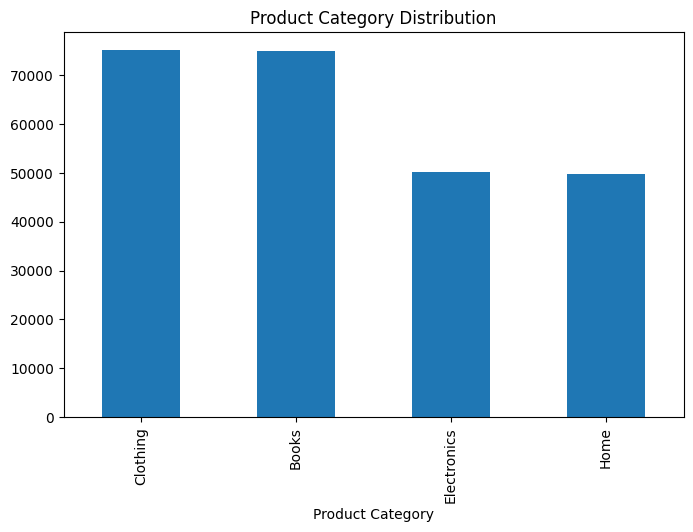

In [18]:
#Product Category Distribution

plt.figure(figsize=(8,5))

df['Product Category'].value_counts().plot(kind='bar')

plt.title("Product Category Distribution")
plt.savefig("product_category.png",dpi=300,bbox_inches="tight")
plt.show()

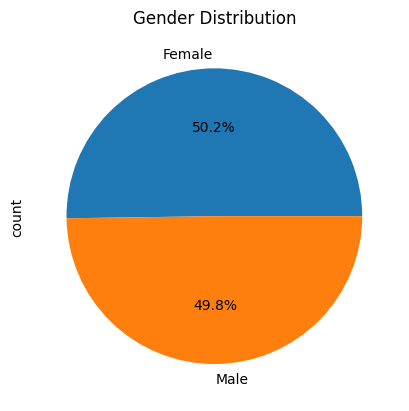

In [19]:
#Gender Distribution
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.savefig("gender_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

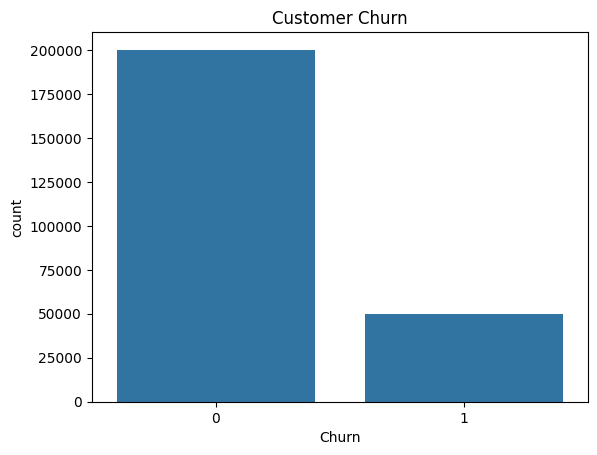

In [20]:
#Churn distribution

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn")
plt.savefig("churn.png",dpi=300,bbox_inches="tight")
plt.show()

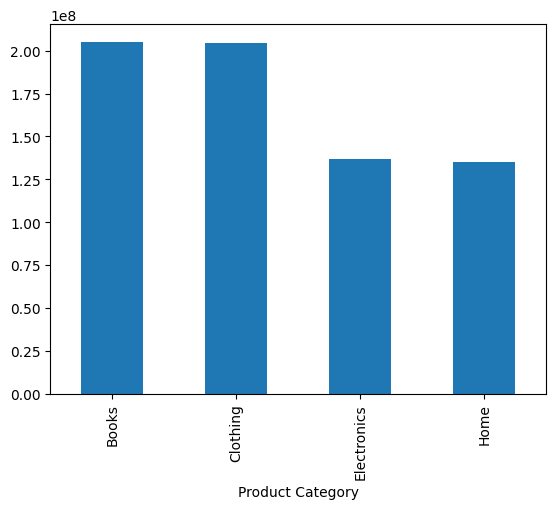

In [21]:
#Revenue by product category

revenue = df.groupby(
    'Product Category'
)['Total Purchase Amount'].sum()

revenue.sort_values(
    ascending=False
).plot(kind='bar')
plt.savefig("rev.png",dpi=300,bbox_inches="tight")

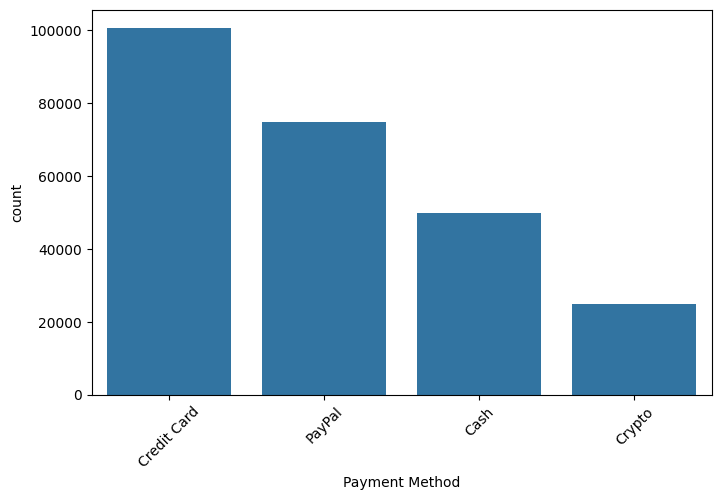

<Figure size 640x480 with 0 Axes>

In [22]:
#payment method analysis

plt.figure(figsize=(8,5))
sns.countplot(
    x='Payment Method',
    data=df
)

plt.xticks(rotation=45)
plt.show()
plt.savefig("payment.png",dpi=300,bbox_inches="tight")

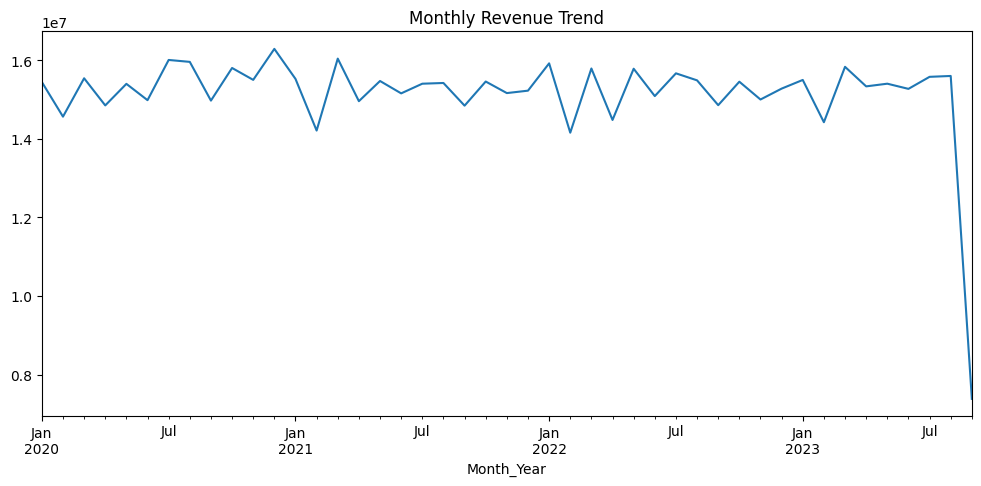

<Figure size 640x480 with 0 Axes>

In [23]:
#Monthly Sales Trend

monthly_sales = df.groupby(
    'Month_Year'
)['Total Purchase Amount'].sum()

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.show()
plt.savefig("monthly.png",dpi=300,bbox_inches="tight")

In [24]:
#customer segmentation(RFM)

snapshot_date = (
    df['Purchase Date'].max()
    + pd.Timedelta(days=1)
)

In [25]:
#Create RFM Table
rfm = df.groupby('Customer ID').agg({

'Purchase Date':
lambda x:
(snapshot_date - x.max()).days,

'Customer ID':'count',

'Total Purchase Amount':'sum'

})

In [26]:
#Rename Columns
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [27]:
#RFM Scoring
rfm['R'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [28]:
#Create Segments
rfm['Segment'] = 'Regular'

rfm.loc[
(rfm['R']==4)&
(rfm['F']==4)&
(rfm['M']==4),
'Segment'
] = 'Champions'

rfm.loc[
(rfm['R']>=3)&
(rfm['F']>=3),
'Segment'
] = 'Loyal Customers'

rfm.loc[
(rfm['R']==1),
'Segment'
] = 'At Risk'

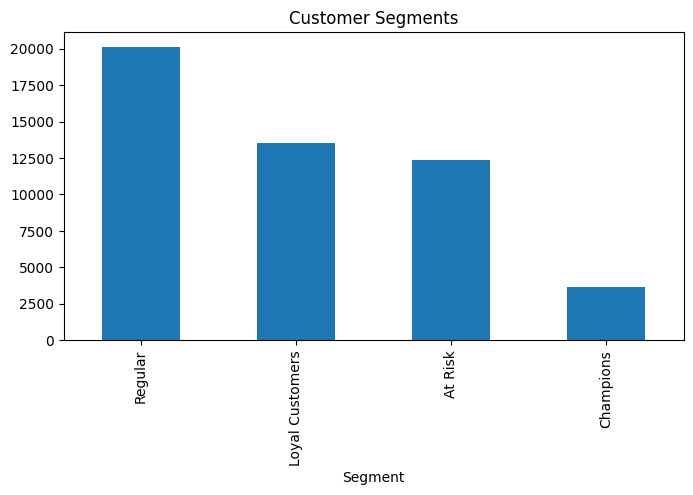

<Figure size 640x480 with 0 Axes>

In [29]:
#Segment Visualization

plt.figure(figsize=(8,4))
rfm['Segment'].value_counts().plot(
kind='bar'
)

plt.title(
"Customer Segments"
)

plt.show()
plt.savefig("segments.png",dpi=300,bbox_inches="tight")

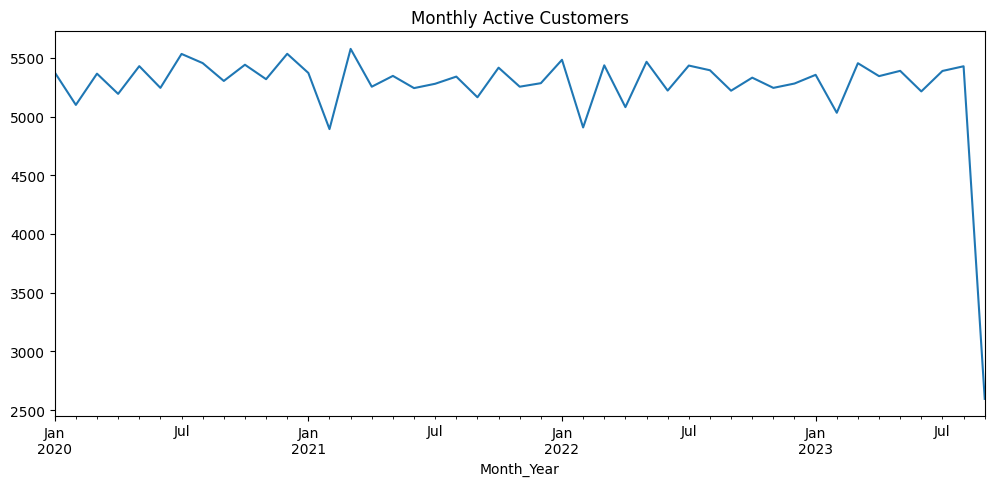

<Figure size 640x480 with 0 Axes>

In [30]:
#Retention Analysis

retention = df.groupby(
'Month_Year'
)['Customer ID'].nunique()

retention.plot(
figsize=(12,5)
)

plt.title(
"Monthly Active Customers"
)

plt.show()
plt.savefig("active.png",dpi=300,bbox_inches="tight")

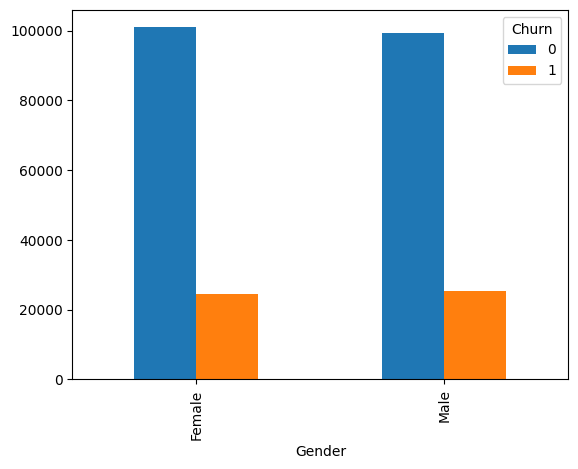

In [31]:
#Churn Analysis

#Churn by Gender
pd.crosstab(
    df['Gender'],
    df['Churn']
).plot(kind='bar')
plt.savefig("churn_gender.png",dpi=300,bbox_inches="tight")

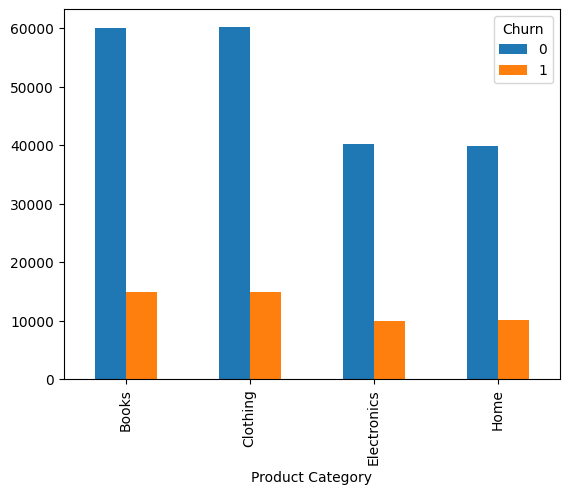

In [32]:
#Churn by Product Category

pd.crosstab(
    df['Product Category'],
    df['Churn']
).plot(kind='bar')
plt.savefig("churn_product.png",dpi=300,bbox_inches="tight")

In [33]:

print("Key Observations:\n")

print("1. Books and Clothing are the most popular product categories, each recording approximately 75,000 purchases, while Electronics and Home categories have comparatively lower purchase volumes.")

print("2. Books and Clothing generate the highest revenue, contributing nearly ₹205 million each, making them the strongest-performing product categories.")

print("3. The customer base is evenly distributed by gender, with Female customers accounting for 50.2% and Male customers accounting for 49.8%, indicating balanced customer participation.")

print("4. Customer churn rate is approximately 20%, with around 50,000 customers churned and 200,000 customers remaining active, highlighting the importance of retention strategies.")

print("5. Credit Card is the most preferred payment method among customers, followed by PayPal, Cash, and Crypto.")

print("6. Monthly revenue trends remain relatively stable throughout the analysis period, indicating consistent business performance with no significant seasonal fluctuations.")

print("7. Monthly active customer counts also remain stable, suggesting steady customer engagement over time.")

print("8. RFM segmentation identified four key customer groups: Regular Customers, Loyal Customers, At-Risk Customers, and Champions.")

print("9. Regular Customers form the largest customer segment, while Loyal Customers contribute significantly to overall business performance.")

print("10. Champions represent the most valuable customers due to their high purchase frequency and spending behavior, despite being the smallest segment.")

print("11. At-Risk Customers represent a substantial portion of the customer base and should be targeted through personalized retention campaigns.")

print("12. Churn patterns appear relatively consistent across genders and product categories, suggesting that retention efforts should focus on overall customer engagement and experience.\n")


print("Key Insights from Customer Behavior Analysis :\n")

# Insights

print("1. Books and Clothing are the most popular product categories, each accounting for approximately 75,000 purchases.")
print("   Insight: Customers show the highest interest in Books and Clothing products compared to Electronics and Home products.\n")

print("2. Books and Clothing generate the highest total revenue, contributing nearly ₹205 million each.")
print("   Insight: These categories are the primary revenue drivers and have the greatest impact on overall business performance.\n")

print("3. Female customers represent 50.2% of the customer base, while Male customers represent 49.8%.")
print("   Insight: The customer base is well-balanced across genders, indicating broad market appeal.\n")

print("4. Approximately 20% of customers have churned, while 80% remain active.")
print("   Insight: Although retention is relatively strong, there is significant opportunity to reduce customer churn.\n")

print("5. Credit Card is the most preferred payment method, followed by PayPal.")
print("   Insight: Customers prefer digital payment options over Cash and Crypto transactions.\n")

print("6. Monthly revenue remains relatively stable throughout the analysis period.")
print("   Insight: Business performance is consistent with no major seasonal fluctuations.\n")

print("7. Monthly active customer counts remain stable over time.")
print("   Insight: Customer engagement levels are steady and predictable.\n")

print("8. RFM segmentation identified Regular Customers as the largest customer segment.")
print("   Insight: Most customers purchase occasionally and can be nurtured into more loyal segments.\n")

print("9. Loyal Customers form a significant portion of the customer base.")
print("   Insight: Existing customer loyalty provides a strong foundation for future growth.\n")

print("10. Champions are the smallest segment but represent the highest-value customers.")
print("    Insight: Retaining these customers is critical because they contribute disproportionately to revenue.\n")

print("11. At-Risk Customers represent a substantial segment.")
print("    Insight: Targeted retention campaigns could prevent future revenue loss.\n")

print("12. Churn patterns are similar across genders and product categories.")
print("    Insight: Customer retention strategies should focus on overall customer experience rather than a specific demographic.\n")

print("Recommendations:")

print("1. Introduce a loyalty rewards program for Champions and Loyal Customers to improve retention and increase lifetime value.")

print("2. Develop targeted re-engagement campaigns for At-Risk Customers using personalized offers and discounts.")

print("3. Increase marketing investments in Books and Clothing categories, as they generate the highest revenue and customer interest.")

print("4. Use customer segmentation insights to create personalized marketing campaigns for different customer groups.")

print("5. Optimize and promote digital payment methods, especially Credit Cards and PayPal, to enhance customer convenience and transaction efficiency.")


Key Observations:

1. Books and Clothing are the most popular product categories, each recording approximately 75,000 purchases, while Electronics and Home categories have comparatively lower purchase volumes.
2. Books and Clothing generate the highest revenue, contributing nearly ₹205 million each, making them the strongest-performing product categories.
3. The customer base is evenly distributed by gender, with Female customers accounting for 50.2% and Male customers accounting for 49.8%, indicating balanced customer participation.
4. Customer churn rate is approximately 20%, with around 50,000 customers churned and 200,000 customers remaining active, highlighting the importance of retention strategies.
5. Credit Card is the most preferred payment method among customers, followed by PayPal, Cash, and Crypto.
6. Monthly revenue trends remain relatively stable throughout the analysis period, indicating consistent business performance with no significant seasonal fluctuations.
7. Monthl